# Assignment-1-PS-5

# NLP Analysis of Amazon Cell Phone Reviews

Team Members Details:

Sl No. : Name : Bits ID : Contribution Percentage

1. SARASWATHI S : 2024AD05063 : 100% contribution
2. NANDAMURI REVANTH SAI : 2024AC05761 : 100% contribution
3. SAKTHI SAKUNTHALA N : 2024ac05633 : 100% contribution
4. J. HEMAVATHI : 2024ac05663 : 100% contribution
5. SURESH M : 2024ac05434 : 100% contribution

## Analysis Tasks:
1. **Dataset Preparation** - Text cleaning and normalization
2. **POS Tagging and Linguistic Pattern Analysis**
3. **Visualization of POS Distribution**
4. **HMM POS Tagging Demonstration**
5. **Combined POS and NER Analysis**

## 1. Import Required Libraries and Load Dataset

In [46]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk
from nltk.tree import Tree

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('maxent_ne_chunker')
nltk.download('words')

# For visualization
from wordcloud import WordCloud
plt.style.use('ggplot')

print("Libraries imported successfully!")

# Initialization

# Configurable parameters for sampling
USE_ALL_SENTENCES = False  # Set to True to process ALL sentences from dataset
SAMPLE_SIZE = 30  # Change this value to process more/fewer sentences (ignored if USE_ALL_SENTENCES=True)
REVIEWS_TO_SAMPLE = 20  # Number of reviews to sample from (ignored if USE_ALL_SENTENCES=True)
SENTENCES_PER_REVIEW = 2  # Sentences to take from each review (ignored if USE_ALL_SENTENCES=True)
MIN_SENTENCE_LENGTH = 6  # Minimum words per sentence

Libraries imported successfully!


[nltk_data] Downloading package punkt to /home/cloud/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/cloud/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/cloud/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/cloud/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /home/cloud/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /home/cloud/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:
# Load the dataset with error handling
try:
    # Try reading with default settings first
    df = pd.read_csv('Amazon_cellphone_reviews.csv')
    print("✓ Dataset loaded successfully with default settings")
except Exception as e:
    print(f"Default loading failed: {str(e)[:100]}")
    print("\nTrying alternative parsing methods...\n")
    
    try:
        # Try with error handling and alternative quoting
        df = pd.read_csv('Amazon_cellphone_reviews.csv', 
                        on_bad_lines='skip',  # Skip problematic lines
                        engine='python',       # Use Python parser (more flexible)
                        encoding='utf-8',
                        quoting=1)            # QUOTE_ALL
        print("✓ Dataset loaded with flexible parser (some rows may be skipped)")
    except Exception as e2:
        print(f"Alternative method 1 failed: {str(e2)[:100]}")
        
        try:
            # Try with even more lenient settings
            df = pd.read_csv('Amazon_cellphone_reviews.csv',
                            on_bad_lines='skip',
                            engine='python',
                            encoding='latin-1',  # Alternative encoding
                            error_bad_lines=False)
            print("✓ Dataset loaded with lenient parser")
        except:
            # Last resort - try different filename
            df = pd.read_csv('Amazon_cellphone_reviews.csv',
                            on_bad_lines='skip',
                            engine='python')
            print("✓ Dataset loaded with alternative filename")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()


Default loading failed: Error tokenizing data. C error: EOF inside string starting at row 247

Trying alternative parsing methods...

Alternative method 1 failed: [Errno 2] No such file or directory: 'Amazon Cell Phone reviews.csv'
✓ Dataset loaded with alternative filename

Dataset shape: (246, 8)
Columns: ['asin', 'name', 'rating', 'date', 'verified', 'title', 'body', 'helpfulVotes']

First few rows:


,asin,name,rating,date,verified,title,body,helpfulVotes
0,B0000SX2UC,Janet,3,"October 11, 2005",False,"Def not best, but not worst",I had the Samsung A600 for awhile which is abs...,1.0
1,B0000SX2UC,Luke Wyatt,1,"January 7, 2004",False,Text Messaging Doesn't Work,Due to a software issue between Nokia and Spri...,17.0
2,B0000SX2UC,Brooke,5,"December 30, 2003",False,Love This Phone,"This is a great, reliable phone. I also purcha...",5.0
3,B0000SX2UC,amy m. teague,3,"March 18, 2004",False,"Love the Phone, BUT...!","I love the phone and all, because I really did...",1.0
4,B0000SX2UC,tristazbimmer,4,"August 28, 2005",False,"Great phone service and options, lousy case!",The phone has been great for every purpose it ...,1.0


In [48]:
# Examine the 'body' column
print(f"Total reviews: {len(df)}")
print(f"Non-null body entries: {df['body'].notna().sum()}")
print(f"Average body length: {df['body'].str.len().mean():.2f} characters")
print("\nSample review bodies:")
for i, body in enumerate(df['body'].dropna().head(3)):
    print(f"\n--- Review {i+1} ---")
    print(body[:300] + "..." if len(body) > 300 else body)

Total reviews: 246
Non-null body entries: 246
Average body length: 454.27 characters

Sample review bodies:

--- Review 1 ---
I had the Samsung A600 for awhile which is absolute doo doo. You can read my review on it and detect my rage at the stupid thing. It finally died on me so I used this Nokia phone I bought in a garage sale for $1. I wonder y she sold it so cheap?... Bad: ===> I hate the menu. It takes forever to get ...

--- Review 2 ---
Due to a software issue between Nokia and Sprint this phone's text messaging capabilities don't work with Sprint's system and won't until a software patch comes out "some time in the next few months". You will have to spend at least 1 hour with Sprint's award winning customer service team to find so...

--- Review 3 ---
This is a great, reliable phone. I also purchased this phone after my samsung A460 died. The menu is easily comprehendable and speed dialing is available for around 300 numbers. Voice dialing is also a nice feature, but it takes l

## 2. Dataset Preparation (2 Marks)

### 2.1 Text Cleaning (1 Mark)
We'll remove punctuation, numeric characters, special symbols, and stop words to ensure only relevant text remains.

In [49]:
# Ensure NLTK data is downloaded properly
import nltk
import ssl

# Fix SSL certificate issues
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK data with error handling
print("Checking and downloading NLTK packages...")
print("=" * 50)

# List of packages to download
packages_to_download = [
    ('punkt', 'tokenizers/punkt'),
    ('punkt_tab', 'tokenizers/punkt_tab/english'),
    ('stopwords', 'corpora/stopwords'),
    ('averaged_perceptron_tagger', 'taggers/averaged_perceptron_tagger'),
    ('wordnet', 'corpora/wordnet')
]

for package_name, package_path in packages_to_download:
    try:
        nltk.data.find(package_path)
        print(f"✓ {package_name} already downloaded")
    except LookupError:
        print(f"Downloading {package_name}...")
        nltk.download(package_name, quiet=False)
        print(f"✓ {package_name} downloaded successfully")

print("=" * 50)
print("All NLTK packages ready!\n")

# Initialize cleaning tools
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean text by removing punctuation, numbers, special characters, and stop words"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs, email addresses
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove numeric characters and special symbols
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters and spaces
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize and remove stop words
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words and len(word) > 2]
    
    return ' '.join(words)

# Apply cleaning to the body column
print("Cleaning text data...")
df['cleaned_body'] = df['body'].apply(clean_text)
print("✓ Text cleaning completed")

# Show before and after examples
print("\nCLEANING DEMONSTRATION:")
print("=" * 50)
for i in range(3):
    original = df['body'].iloc[i]
    cleaned = df['cleaned_body'].iloc[i]
    
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {original[:200]}...")
    print(f"Cleaned:  {cleaned[:200]}...")
    print()

print(f"\nAverage length before cleaning: {df['body'].str.len().mean():.2f}")
print(f"Average length after cleaning: {df['cleaned_body'].str.len().mean():.2f}")

[nltk_data] Downloading package wordnet to /home/cloud/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Checking and downloading NLTK packages...
✓ punkt already downloaded
✓ punkt_tab already downloaded
✓ stopwords already downloaded
✓ averaged_perceptron_tagger already downloaded
✓ wordnet downloaded successfully
All NLTK packages ready!

Cleaning text data...
✓ Text cleaning completed

CLEANING DEMONSTRATION:

--- Example 1 ---
Original: I had the Samsung A600 for awhile which is absolute doo doo. You can read my review on it and detect my rage at the stupid thing. It finally died on me so I used this Nokia phone I bought in a garage ...
Cleaned:  samsung awhile absolute doo doo read review detect rage stupid thing finally died used nokia phone bought garage sale wonder sold cheap bad hate menu takes forever get want scroll endlessly usually ph...


--- Example 2 ---
Original: Due to a software issue between Nokia and Sprint this phone's text messaging capabilities don't work with Sprint's system and won't until a software patch comes out "some time in the next few months"....
Cleaned

**Justification for Cleaning Process:**
- **Punctuation removal**: Eliminates noise that doesn't contribute to semantic meaning
- **Numeric removal**: Phone model numbers and dates don't add linguistic value for POS analysis
- **Stop words removal**: Common words like 'the', 'and', 'is' don't carry significant semantic weight
- **Lowercasing**: Ensures consistency and reduces vocabulary size
- **Length filtering**: Removes very short words that are often meaningless

### 2.2 Text Normalization (1 Mark)
Apply stemming and lemmatization to convert words into their standardized base forms.

In [50]:
# Download additional NLTK data for lemmatization
print("Checking additional NLTK packages for lemmatization...")
print("=" * 50)

# List of additional packages needed
additional_packages = [
    ('omw-1.4', 'corpora/omw-1.4'),
    ('averaged_perceptron_tagger_eng', 'taggers/averaged_perceptron_tagger_eng')
]

for package_name, package_path in additional_packages:
    try:
        nltk.data.find(package_path)
        print(f"✓ {package_name} already downloaded")
    except LookupError:
        print(f"Downloading {package_name}...")
        nltk.download(package_name, quiet=False)
        print(f"✓ {package_name} downloaded successfully")

print("=" * 50)
print()

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Convert POS tag to format accepted by WordNetLemmatizer"""
    if treebank_tag.startswith('J'):
        return 'a'  # adjective
    elif treebank_tag.startswith('V'):
        return 'v'  # verb
    elif treebank_tag.startswith('N'):
        return 'n'  # noun
    elif treebank_tag.startswith('R'):
        return 'r'  # adverb
    else:
        return 'n'  # default to noun

def apply_stemming(text):
    """Apply Porter stemming to text"""
    if not text:
        return ""
    words = word_tokenize(text)
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

def apply_lemmatization(text):
    """Apply POS-aware lemmatization to text"""
    if not text:
        return ""
    words = word_tokenize(text)
    # Get POS tags for each word
    pos_tags = pos_tag(words)
    # Apply lemmatization with appropriate POS tags
    lemmatized_words = []
    for word, pos in pos_tags:
        wordnet_pos = get_wordnet_pos(pos)
        lemmatized_word = lemmatizer.lemmatize(word, pos=wordnet_pos)
        lemmatized_words.append(lemmatized_word)
    return ' '.join(lemmatized_words)

# Apply both techniques to a subset for comparison
sample_texts = df['cleaned_body'].head(100).tolist()
sample_texts = [text for text in sample_texts if text]  # Remove empty strings

print("Applying stemming and lemmatization...")
# Apply stemming and POS-aware lemmatization
df['stemmed_body'] = df['cleaned_body'].apply(apply_stemming)
df['lemmatized_body'] = df['cleaned_body'].apply(apply_lemmatization)
print("✓ Normalization completed")

# Comparison examples
print("\nNORMALIZATION COMPARISON:")
print("=" * 60)

sample_words = ['running', 'better', 'phones', 'charging', 'features', 'broken', 'batteries', 'amazed', 'loving', 'worked']
print(f"{'Original':<12} {'Stemmed':<12} {'POS-Aware Lemma':<16}")
print("-" * 45)
for word in sample_words:
    stemmed = stemmer.stem(word)
    
    # For POS-aware lemmatization, we need to determine POS
    pos_tag_result = pos_tag([word])
    wordnet_pos = get_wordnet_pos(pos_tag_result[0][1])
    pos_lemma = lemmatizer.lemmatize(word, pos=wordnet_pos)
    
    print(f"{word:<12} {stemmed:<12} {pos_lemma:<16}")

print("\n--- Text Examples ---")
for i in range(2):
    if df['cleaned_body'].iloc[i]:
        print(f"\nExample {i+1}:")
        print(f"Cleaned:        {df['cleaned_body'].iloc[i][:80]}...")
        print(f"Stemmed:        {df['stemmed_body'].iloc[i][:80]}...")
        print(f"POS Lemma:      {df['lemmatized_body'].iloc[i][:80]}...")

# Choose POS-aware lemmatization for better linguistic analysis
df['processed_body'] = df['lemmatized_body']
print("\n*** Using POS-aware lemmatized text for further analysis ***")

# Demonstrate the effectiveness of POS-aware lemmatization
print("\n" + "=" * 60)
print("POS-AWARE LEMMATIZATION EFFECTIVENESS:")
print("=" * 60)
verb_examples = ['running', 'worked', 'charging', 'loving', 'broken', 'amazing', 'using', 'calling']
print(f"{'Original Word':<15} {'Lemmatized Form':<18} {'POS Detected'}")
print("-" * 50)
for word in verb_examples:
    pos_tag_result = pos_tag([word])
    detected_pos = pos_tag_result[0][1]
    wordnet_pos = get_wordnet_pos(detected_pos)
    lemmatized = lemmatizer.lemmatize(word, pos=wordnet_pos)
    print(f"{word:<15} {lemmatized:<18} {detected_pos}")

print("\nBenefits of POS-Aware Lemmatization:")
print("• Verbs are properly reduced to their base forms")
print("• Context-aware processing maintains semantic accuracy")
print("• Essential for high-quality NLP preprocessing and analysis")

Checking additional NLTK packages for lemmatization...
✓ omw-1.4 downloaded successfully
✓ averaged_perceptron_tagger_eng already downloaded

Applying stemming and lemmatization...


[nltk_data] Downloading package omw-1.4 to /home/cloud/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✓ Normalization completed

NORMALIZATION COMPARISON:
Original     Stemmed      POS-Aware Lemma 
---------------------------------------------
running      run          run             
better       better       well            
phones       phone        phone           
charging     charg        charge          
features     featur       feature         
broken       broken       broken          
batteries    batteri      battery         
amazed       amaz         amaze           
loving       love         love            
worked       work         work            

--- Text Examples ---

Example 1:
Cleaned:        samsung awhile absolute doo doo read review detect rage stupid thing finally die...
Stemmed:        samsung awhil absolut doo doo read review detect rage stupid thing final die use...
POS Lemma:      samsung awhile absolute doo doo read review detect rage stupid thing finally die...

Example 2:
Cleaned:        due software issue nokia sprint phones text messaging capabilitie

**Justification for Normalization Choice:**

### Stemming vs Lemmatization Comparison:
- **Stemming**: Faster but overly aggressive - removes suffixes without considering meaning
  - Example: 'running' → 'run', 'better' → 'better' 
  - Can produce non-words: 'studies' → 'studi'

- **Simple Lemmatization**: More accurate than stemming but limited without POS context
  - Example: 'running' → 'running' (fails to identify it as a verb)
  - Treats all words as nouns by default

- **POS-Aware Lemmatization**: Most accurate - uses grammatical context for proper reduction
  - Example: 'running' → 'run' (correctly identifies as verb)
  - Example: 'worked' → 'work', 'loving' → 'love'
  - Preserves word meaning while reducing vocabulary

### Why POS-Aware Lemmatization is Essential:
1. **Verb Forms**: Properly converts verb inflections ('running' → 'run', 'worked' → 'work')
2. **Contextual Accuracy**: Same word form treated differently based on POS
3. **NLP Task Performance**: Critical for accurate text analysis and pattern recognition
4. **Semantic Preservation**: Maintains semantic relationships while normalizing forms

### Selection Rationale:
- **Chosen**: POS-aware lemmatization for superior accuracy in grammatical analysis
- **Benefit**: Reduces vocabulary while preserving precise linguistic relationships
- **Application**: Essential for meaningful POS tagging and pattern analysis in subsequent steps

## 3. POS Tagging and Linguistic Pattern Analysis (3 Marks)

In [51]:
# Prepare data for POS tagging - use original text for better POS accuracy
# We'll use cleaned but not heavily processed text for POS tagging
def light_clean_for_pos(text):
    """Light cleaning that preserves sentence structure for POS tagging"""
    if pd.isna(text):
        return ""
    # Remove only excessive punctuation, keep sentence structure
    text = re.sub(r'[^a-zA-Z0-9\s.,!?;:]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['pos_ready_text'] = df['body'].apply(light_clean_for_pos)


# Sample sentences for POS analysis
sample_sentences = []

if USE_ALL_SENTENCES:
    print("🌍 PROCESSING ALL SENTENCES FROM ENTIRE DATASET")
    print("⚠️  Warning: This may take several minutes for large datasets")
    
    # Process all reviews
    for text in df['pos_ready_text']:
        if text:
            sentences = sent_tokenize(text)
            sample_sentences.extend(sentences)
    
    # Filter by minimum length only
    sample_sentences = [s for s in sample_sentences if len(s.split()) >= MIN_SENTENCE_LENGTH]
    
else:
    # Use sampling approach
    for text in df['pos_ready_text'].head(REVIEWS_TO_SAMPLE):
        if text:
            sentences = sent_tokenize(text)
            sample_sentences.extend(sentences[:SENTENCES_PER_REVIEW])
    
    # Remove very short sentences and limit to desired sample size
    sample_sentences = [s for s in sample_sentences if len(s.split()) >= MIN_SENTENCE_LENGTH][:SAMPLE_SIZE]

print(f"Sampling Configuration:")
if USE_ALL_SENTENCES:
    print(f"• Mode: FULL DATASET PROCESSING")
    print(f"• Total reviews processed: {len(df)}")
    print(f"• Minimum sentence length: {MIN_SENTENCE_LENGTH} words")
    print(f"• Total sentences obtained: {len(sample_sentences)} sentences")
else:
    print(f"• Mode: SAMPLED PROCESSING")
    print(f"• Target sample size: {SAMPLE_SIZE} sentences")
    print(f"• Reviews sampled: {REVIEWS_TO_SAMPLE}")
    print(f"• Sentences per review: {SENTENCES_PER_REVIEW}")
    print(f"• Minimum sentence length: {MIN_SENTENCE_LENGTH} words")
    print(f"• Actual sample obtained: {len(sample_sentences)} sentences")

if len(sample_sentences) > 0:
    avg_length = sum(len(s.split()) for s in sample_sentences) / len(sample_sentences)
    total_words = sum(len(s.split()) for s in sample_sentences)
    print(f"• Average sentence length: {avg_length:.1f} words")
    print(f"• Total words in sample: {total_words:,} words")
    
    if USE_ALL_SENTENCES:
        print(f"\n⏱️ Processing time estimate: ~{len(sample_sentences) // 100 + 1}-{len(sample_sentences) // 50 + 2} minutes")
    
    print(f"\nFirst 5 sample sentences:")
    for i, sentence in enumerate(sample_sentences[:5]):
        print(f"{i+1}. {sentence}")
else:
    print("⚠️ No sentences found matching criteria. Adjust parameters.")


Sampling Configuration:
• Mode: SAMPLED PROCESSING
• Target sample size: 30 sentences
• Reviews sampled: 20
• Sentences per review: 2
• Minimum sentence length: 6 words
• Actual sample obtained: 30 sentences
• Average sentence length: 23.4 words
• Total words in sample: 703 words

First 5 sample sentences:
1. I had the Samsung A600 for awhile which is absolute doo doo.
2. You can read my review on it and detect my rage at the stupid thing.
3. Due to a software issue between Nokia and Sprint this phones text messaging capabilities dont work with Sprints system and wont until a software patch comes out some time in the next few months.
4. You will have to spend at least 1 hour with Sprints award winning customer service team to find someone who will admit this to you.
5. This is a great, reliable phone.


In [52]:
# Apply POS tagging to sample sentences
def get_pos_tags(sentences):
    """Apply POS tagging to a list of sentences"""
    tagged_sentences = []
    all_tags = []
    
    for sentence in sentences:
        words = word_tokenize(sentence)
        pos_tags = pos_tag(words)
        tagged_sentences.append(pos_tags)
        all_tags.extend([tag for word, tag in pos_tags])
    
    return tagged_sentences, all_tags

# Get POS tags
tagged_sentences, all_pos_tags = get_pos_tags(sample_sentences)

print("\nPOS tagging completed.")
print(sample_sentences[:5])
print(tagged_sentences[:5])

# Display POS tagging results
print("POS TAGGING RESULTS:")
print("=" * 50)
for i, (sentence, tags) in enumerate(zip(sample_sentences[:5], tagged_sentences[:5])):
    print(f"\nSentence {i+1}: {sentence}")
    print("POS Tags:")
    for word, tag in tags:
        print(f"  {word:<15} -> {tag}")

# Count POS tag frequencies
pos_counts = Counter(all_pos_tags)
print(f"\n\nMost common POS tags:")
for tag, count in pos_counts.most_common(10):
    print(f"{tag:<5}: {count:>3} occurrences")


POS tagging completed.
['I had the Samsung A600 for awhile which is absolute doo doo.', 'You can read my review on it and detect my rage at the stupid thing.', 'Due to a software issue between Nokia and Sprint this phones text messaging capabilities dont work with Sprints system and wont until a software patch comes out some time in the next few months.', 'You will have to spend at least 1 hour with Sprints award winning customer service team to find someone who will admit this to you.', 'This is a great, reliable phone.']
[[('I', 'PRP'), ('had', 'VBD'), ('the', 'DT'), ('Samsung', 'NNP'), ('A600', 'NNP'), ('for', 'IN'), ('awhile', 'NN'), ('which', 'WDT'), ('is', 'VBZ'), ('absolute', 'JJ'), ('doo', 'NN'), ('doo', 'NN'), ('.', '.')], [('You', 'PRP'), ('can', 'MD'), ('read', 'VB'), ('my', 'PRP$'), ('review', 'NN'), ('on', 'IN'), ('it', 'PRP'), ('and', 'CC'), ('detect', 'VB'), ('my', 'PRP$'), ('rage', 'NN'), ('at', 'IN'), ('the', 'DT'), ('stupid', 'JJ'), ('thing', 'NN'), ('.', '.')], [('D

In [53]:
# Function to find sentences with specific POS categories
def find_sentences_with_pos(tagged_sentences, original_sentences, target_pos):
    """Find sentences containing specific POS tags"""
    matching_sentences = []
    
    for i, tags in enumerate(tagged_sentences):
        pos_tags_in_sentence = [tag for word, tag in tags]
        
        if any(pos in pos_tags_in_sentence for pos in target_pos):
            matching_sentences.append({
                'sentence': original_sentences[i],
                'tags': tags,
                'matched_pos': [pos for pos in target_pos if pos in pos_tags_in_sentence]
            })
    
    return matching_sentences

# Define target POS categories
target_categories = {
    'nouns': ['NN', 'NNS', 'NNP', 'NNPS'],
    'verbs': ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'],
    'adverbs': ['RB', 'RBR', 'RBS'],
    'adjectives': ['JJ', 'JJR', 'JJS']
}

# Find sentences with each category
print("SENTENCES WITH TARGETED POS CATEGORIES:")
print("=" * 60)

for category, pos_list in target_categories.items():
    matches = find_sentences_with_pos(tagged_sentences, sample_sentences, pos_list)
    
    print(f"\n{category.upper()} ({', '.join(pos_list)}):")
    print(f"Found {len(matches)} sentences")
    
    # Show first 3 examples
    for i, match in enumerate(matches[:3]):
        print(f"\n  Example {i+1}: {match['sentence']}")
        # Highlight target POS words
        target_words = [word for word, tag in match['tags'] if tag in pos_list]
        print(f"  {category.title()} found: {', '.join(target_words)}")

SENTENCES WITH TARGETED POS CATEGORIES:

NOUNS (NN, NNS, NNP, NNPS):
Found 30 sentences

  Example 1: I had the Samsung A600 for awhile which is absolute doo doo.
  Nouns found: Samsung, A600, awhile, doo, doo

  Example 2: You can read my review on it and detect my rage at the stupid thing.
  Nouns found: review, rage, thing

  Example 3: Due to a software issue between Nokia and Sprint this phones text messaging capabilities dont work with Sprints system and wont until a software patch comes out some time in the next few months.
  Nouns found: software, issue, Nokia, Sprint, phones, capabilities, work, Sprints, system, wont, software, patch, time, months

VERBS (VB, VBD, VBG, VBN, VBP, VBZ):
Found 30 sentences

  Example 1: I had the Samsung A600 for awhile which is absolute doo doo.
  Verbs found: had, is

  Example 2: You can read my review on it and detect my rage at the stupid thing.
  Verbs found: read, detect

  Example 3: Due to a software issue between Nokia and Sprint this p

### 3.2 Explore Repeating Linguistic Structures

In [54]:
# Function to find linguistic patterns
def find_linguistic_patterns(tagged_sentences):
    """Find common linguistic structures in tagged sentences"""
    patterns = {
        'noun_noun': [],        # NN + NN compounds
        'verb_noun': [],        # VB + NN objects
        'adj_noun': [],         # JJ + NN phrases
        'adv_verb': [],         # RB + VB phrases
        'adv_adj': []          # RB + JJ phrases
    }
    
    for sentence_tags in tagged_sentences:
        for i in range(len(sentence_tags) - 1):
            word1, pos1 = sentence_tags[i]
            word2, pos2 = sentence_tags[i + 1]
            
            # Noun + Noun compounds
            if pos1 in ['NN', 'NNP'] and pos2 in ['NN', 'NNS', 'NNP']:
                patterns['noun_noun'].append(f"{word1} {word2}")
            
            # Verb + Noun objects
            elif pos1.startswith('VB') and pos2 in ['NN', 'NNS', 'NNP']:
                patterns['verb_noun'].append(f"{word1} {word2}")
            
            # Adjective + Noun phrases
            elif pos1 in ['JJ', 'JJR', 'JJS'] and pos2 in ['NN', 'NNS', 'NNP']:
                patterns['adj_noun'].append(f"{word1} {word2}")
            
            # Adverb + Verb phrases
            elif pos1 in ['RB', 'RBR', 'RBS'] and pos2.startswith('VB'):
                patterns['adv_verb'].append(f"{word1} {word2}")
            
            # Adverb + Adjective phrases
            elif pos1 in ['RB', 'RBR', 'RBS'] and pos2 in ['JJ', 'JJR', 'JJS']:
                patterns['adv_adj'].append(f"{word1} {word2}")
    
    return patterns

# Find patterns
linguistic_patterns = find_linguistic_patterns(tagged_sentences)

print("REPEATING LINGUISTIC STRUCTURES:")
print("=" * 50)

for pattern_type, phrases in linguistic_patterns.items():
    if phrases:
        phrase_counts = Counter(phrases)
        print(f"\n{pattern_type.replace('_', ' + ').upper()} PATTERNS:")
        print(f"Total found: {len(phrases)}, Unique: {len(phrase_counts)}")
        
        # Show most common patterns
        print("Most common:")
        for phrase, count in phrase_counts.most_common(5):
            print(f"  '{phrase}' - {count} times")
        
        # Show some examples
        if len(phrase_counts) > 5:
            print("Other examples:", ', '.join(list(phrase_counts.keys())[5:10]))

REPEATING LINGUISTIC STRUCTURES:

NOUN + NOUN PATTERNS:
Total found: 32, Unique: 31
Most common:
  'text messaging' - 2 times
  'Samsung A600' - 1 times
  'doo doo' - 1 times
  'software issue' - 1 times
  'Sprints system' - 1 times
Other examples: Sprints award, customer service, service team, samsung A460, iti couldnt

VERB + NOUN PATTERNS:
Total found: 10, Unique: 10
Most common:
  'messaging capabilities' - 1 times
  'winning customer' - 1 times
  'find someone' - 1 times
  'bought iti' - 1 times
  'NO problems' - 1 times
Other examples: headset jack, tech support, flip phones, reciving calls, worked wonders

ADJ + NOUN PATTERNS:
Total found: 32, Unique: 31
Most common:
  'new customers' - 2 times
  'absolute doo' - 1 times
  'stupid thing' - 1 times
  'dont work' - 1 times
  'few months' - 1 times
Other examples: free accessories, own pictures, super cool, storean employee, new casesit

ADV + VERB PATTERNS:
Total found: 11, Unique: 10
Most common:
  'ever had' - 2 times
  'also pu

### 3.3 Analysis of Structural Patterns and Their Contribution

In [55]:
# Analyze the significance of found patterns
print("LINGUISTIC PATTERN ANALYSIS:")
print("=" * 60)

pattern_analysis = {
    'noun_noun': {
        'description': 'Noun + Noun Compounds',
        'meaning_contribution': 'Create specific technical terms and product features',
        'nlp_applications': 'Entity recognition, feature extraction, domain terminology',
        'examples': linguistic_patterns['noun_noun'][:5]
    },
    'verb_noun': {
        'description': 'Verb + Noun Objects',
        'meaning_contribution': 'Express actions and their targets, core semantic relationships',
        'nlp_applications': 'Semantic role labeling, action extraction, sentiment analysis',
        'examples': linguistic_patterns['verb_noun'][:5]
    },
    'adj_noun': {
        'description': 'Adjective + Noun Phrases',
        'meaning_contribution': 'Provide descriptive qualities and evaluative content',
        'nlp_applications': 'Sentiment analysis, opinion mining, feature description',
        'examples': linguistic_patterns['adj_noun'][:5]
    },
    'adv_verb': {
        'description': 'Adverb + Verb Phrases',
        'meaning_contribution': 'Modify actions with intensity, manner, or degree',
        'nlp_applications': 'Sentiment intensity, aspect-based analysis',
        'examples': linguistic_patterns['adv_verb'][:5]
    },
    'adv_adj': {
        'description': 'Adverb + Adjective Phrases',
        'meaning_contribution': 'Intensify or modify descriptive qualities',
        'nlp_applications': 'Sentiment scoring, opinion strength measurement',
        'examples': linguistic_patterns['adv_adj'][:5]
    }
}

for pattern_type, analysis in pattern_analysis.items():
    if linguistic_patterns[pattern_type]:
        print(f"\n{analysis['description']}:")
        print(f"• Meaning: {analysis['meaning_contribution']}")
        print(f"• NLP Applications: {analysis['nlp_applications']}")
        print(f"• Examples: {', '.join(analysis['examples'])}")

print("\n" + "=" * 60)
print("OVERALL CONTRIBUTION TO NLP TASKS:")
print("\n1. TEXT SUMMARIZATION:")
print("   - Noun compounds identify key product features")
print("   - Verb-noun pairs capture main actions and issues")
print("   - Adjective-noun phrases highlight important qualities")

print("\n2. SEMANTIC ROLE LABELING:")
print("   - POS patterns help identify agents, actions, and patients")
print("   - Structural consistency aids in role assignment")
print("   - Linguistic patterns reveal semantic relationships")

print("\n3. SENTIMENT ANALYSIS:")
print("   - Adjective-noun patterns carry evaluative content")
print("   - Adverb modifications indicate intensity")
print("   - Pattern frequency suggests sentiment distribution")

LINGUISTIC PATTERN ANALYSIS:

Noun + Noun Compounds:
• Meaning: Create specific technical terms and product features
• NLP Applications: Entity recognition, feature extraction, domain terminology
• Examples: Samsung A600, doo doo, software issue, Sprints system, software patch

Verb + Noun Objects:
• Meaning: Express actions and their targets, core semantic relationships
• NLP Applications: Semantic role labeling, action extraction, sentiment analysis
• Examples: messaging capabilities, winning customer, find someone, bought iti, NO problems

Adjective + Noun Phrases:
• Meaning: Provide descriptive qualities and evaluative content
• NLP Applications: Sentiment analysis, opinion mining, feature description
• Examples: absolute doo, stupid thing, dont work, few months, reliable phone

Adverb + Verb Phrases:
• Meaning: Modify actions with intensity, manner, or degree
• NLP Applications: Sentiment intensity, aspect-based analysis
• Examples: also purchased, really did, still have, never ow

## 4. Visualization of POS Distribution (1 Mark)

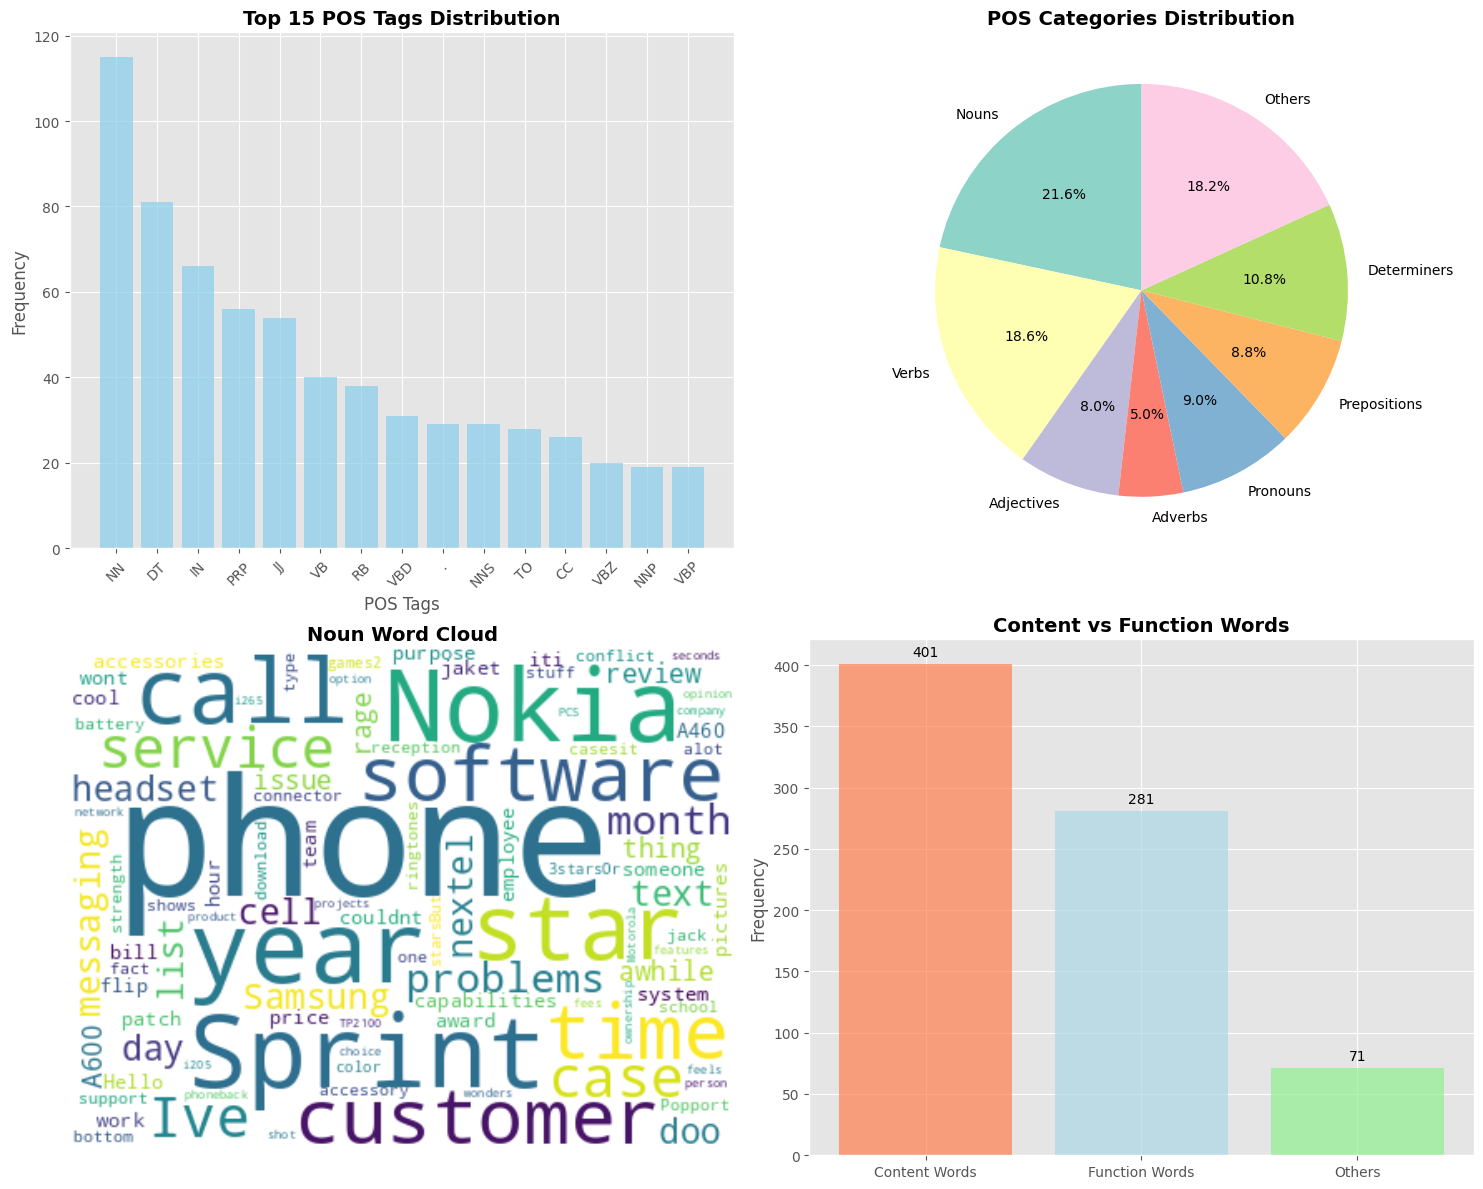


POS DISTRIBUTION SUMMARY:
Total POS tags analyzed: 753
Unique POS tags found: 28
Content words: 401 (53.3%)
Function words: 281 (37.3%)

Top 5 POS tags:
  NN: 115 (15.3%)
  DT: 81 (10.8%)
  IN: 66 (8.8%)
  PRP: 56 (7.4%)
  JJ: 54 (7.2%)


In [56]:
# Create visualizations of POS tag distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Bar plot of most common POS tags
pos_counts = Counter(all_pos_tags)
top_pos = dict(pos_counts.most_common(15))

axes[0, 0].bar(top_pos.keys(), top_pos.values(), color='skyblue', alpha=0.7)
axes[0, 0].set_title('Top 15 POS Tags Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('POS Tags')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Pie chart of major POS categories
major_categories = {
    'Nouns': ['NN', 'NNS', 'NNP', 'NNPS'],
    'Verbs': ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'],
    'Adjectives': ['JJ', 'JJR', 'JJS'],
    'Adverbs': ['RB', 'RBR', 'RBS'],
    'Pronouns': ['PRP', 'PRP$'],
    'Prepositions': ['IN'],
    'Determiners': ['DT'],
    'Others': []  # Will be calculated
}

category_counts = {}
categorized_tags = set()

for category, tags in major_categories.items():
    if category != 'Others':
        count = sum(pos_counts[tag] for tag in tags if tag in pos_counts)
        category_counts[category] = count
        categorized_tags.update(tags)

# Calculate 'Others' category
others_count = sum(count for tag, count in pos_counts.items() if tag not in categorized_tags)
category_counts['Others'] = others_count

axes[0, 1].pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%',
               startangle=90, colors=plt.cm.Set3.colors)
axes[0, 1].set_title('POS Categories Distribution', fontsize=14, fontweight='bold')

# 3. Word cloud of most common words by POS
noun_words = [word for word, tag in sum(tagged_sentences, []) if tag.startswith('NN')]
noun_text = ' '.join(noun_words)

if noun_text:
    wordcloud = WordCloud(width=400, height=300, background_color='white',
                         colormap='viridis').generate(noun_text)
    axes[1, 0].imshow(wordcloud, interpolation='bilinear')
    axes[1, 0].set_title('Noun Word Cloud', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

# 4. Comparative frequency of content vs function words
content_words = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS']
function_words = ['DT', 'IN', 'TO', 'CC', 'PRP', 'PRP$', 'WP', 'WDT', 'MD']

content_count = sum(pos_counts[tag] for tag in content_words if tag in pos_counts)
function_count = sum(pos_counts[tag] for tag in function_words if tag in pos_counts)
other_count = sum(pos_counts.values()) - content_count - function_count

categories = ['Content Words', 'Function Words', 'Others']
counts = [content_count, function_count, other_count]

axes[1, 1].bar(categories, counts, color=['coral', 'lightblue', 'lightgreen'], alpha=0.7)
axes[1, 1].set_title('Content vs Function Words', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Frequency')

# Add value labels on bars
for i, v in enumerate(counts):
    axes[1, 1].text(i, v + max(counts) * 0.01, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPOS DISTRIBUTION SUMMARY:")
print("=" * 40)
print(f"Total POS tags analyzed: {len(all_pos_tags)}")
print(f"Unique POS tags found: {len(pos_counts)}")
print(f"Content words: {content_count} ({content_count/len(all_pos_tags)*100:.1f}%)")
print(f"Function words: {function_count} ({function_count/len(all_pos_tags)*100:.1f}%)")

print("\nTop 5 POS tags:")
for tag, count in pos_counts.most_common(5):
    percentage = (count / len(all_pos_tags)) * 100
    print(f"  {tag}: {count} ({percentage:.1f}%)")

**Justification for Visualizations:**
- **Bar Chart**: Shows absolute frequencies of POS tags, revealing dominant grammatical categories
- **Pie Chart**: Provides proportional view of major POS categories for easy comparison
- **Word Cloud**: Visualizes most frequent nouns, highlighting key topics in reviews
- **Content vs Function Words**: Shows balance between meaningful content and grammatical structure

In [57]:
# Implement a simplified HMM POS tagger
import numpy as np
from collections import defaultdict

class SimpleHMMTagger:
    def __init__(self):
        self.emission_prob = defaultdict(lambda: defaultdict(float))
        self.transition_prob = defaultdict(lambda: defaultdict(float))
        self.tag_counts = defaultdict(int)
        self.word_counts = defaultdict(int)
        self.tags = set()
        
    def train(self, tagged_sentences):
        """Train the HMM model on tagged sentences"""
        # Count emissions and transitions
        for sentence in tagged_sentences:
            prev_tag = '<START>'
            
            for word, tag in sentence:
                word = word.lower()
                
                # Count emissions: P(word|tag)
                self.emission_prob[tag][word] += 1
                self.tag_counts[tag] += 1
                self.word_counts[word] += 1
                self.tags.add(tag)
                
                # Count transitions: P(tag|prev_tag)
                self.transition_prob[prev_tag][tag] += 1
                
                prev_tag = tag
            
            # End of sentence
            self.transition_prob[prev_tag]['<END>'] += 1
        
        # Convert counts to probabilities
        self._normalize_probabilities()
    
    def _normalize_probabilities(self):
        """Convert counts to probabilities"""
        # Normalize emission probabilities
        for tag in self.emission_prob:
            total = sum(self.emission_prob[tag].values())
            for word in self.emission_prob[tag]:
                self.emission_prob[tag][word] /= total
        
        # Normalize transition probabilities
        for prev_tag in self.transition_prob:
            total = sum(self.transition_prob[prev_tag].values())
            if total > 0:
                for tag in self.transition_prob[prev_tag]:
                    self.transition_prob[prev_tag][tag] /= total
    
    def viterbi_decode(self, sentence):
        """Use Viterbi algorithm for POS tagging"""
        words = [word.lower() for word in sentence]
        n_words = len(words)
        tags = list(self.tags)
        n_tags = len(tags)
        
        # Initialize Viterbi matrices
        viterbi = np.zeros((n_tags, n_words))
        backpointer = np.zeros((n_tags, n_words), dtype=int)
        
        # Handle unknown words with smoothing
        def get_emission_prob(tag, word):
            if word in self.emission_prob[tag]:
                return self.emission_prob[tag][word]
            else:
                return 1e-6  # Small probability for unknown words
        
        def get_transition_prob(prev_tag, tag):
            if tag in self.transition_prob[prev_tag]:
                return self.transition_prob[prev_tag][tag]
            else:
                return 1e-6
        
        # Initialize first word
        for i, tag in enumerate(tags):
            viterbi[i, 0] = (get_transition_prob('<START>', tag) * 
                            get_emission_prob(tag, words[0]))
        
        # Forward pass
        for t in range(1, n_words):
            for i, tag in enumerate(tags):
                max_prob = 0
                max_prev = 0
                
                for j, prev_tag in enumerate(tags):
                    prob = (viterbi[j, t-1] * 
                           get_transition_prob(prev_tag, tag) * 
                           get_emission_prob(tag, words[t]))
                    
                    if prob > max_prob:
                        max_prob = prob
                        max_prev = j
                
                viterbi[i, t] = max_prob
                backpointer[i, t] = max_prev
        
        # Backward pass - find best path
        best_path = [0] * n_words
        best_path[-1] = np.argmax(viterbi[:, -1])
        
        for t in range(n_words - 2, -1, -1):
            best_path[t] = backpointer[best_path[t + 1], t + 1]
        
        # Convert indices back to tags
        predicted_tags = [tags[i] for i in best_path]
        
        return list(zip(sentence, predicted_tags))

# Train the HMM tagger
print("Training HMM POS Tagger...")
hmm_tagger = SimpleHMMTagger()
hmm_tagger.train(tagged_sentences)
print(f"Training completed with {len(hmm_tagger.tags)} POS tags")

# Test on first four entries
test_sentences = sample_sentences[:4]
print("\nHMM POS TAGGING RESULTS (First 4 entries):")
print("=" * 60)

for i, sentence in enumerate(test_sentences):
    words = word_tokenize(sentence)
    
    # Get NLTK tags for comparison
    nltk_tags = pos_tag(words)
    
    # Get HMM tags
    hmm_tags = hmm_tagger.viterbi_decode(words)
    
    print(f"\n--- Sentence {i+1} ---")
    print(f"Text: {sentence}")
    print("\nComparison (NLTK vs HMM):")
    print(f"{'Word':<15} {'NLTK':<8} {'HMM':<8} {'Match':<6}")
    print("-" * 45)
    
    matches = 0
    for (word_nltk, tag_nltk), (word_hmm, tag_hmm) in zip(nltk_tags, hmm_tags):
        match = "✓" if tag_nltk == tag_hmm else "✗"
        if tag_nltk == tag_hmm:
            matches += 1
        print(f"{word_nltk:<15} {tag_nltk:<8} {tag_hmm:<8} {match:<6}")
    
    accuracy = matches / len(words) * 100
    print(f"\nAccuracy: {matches}/{len(words)} ({accuracy:.1f}%)")

Training HMM POS Tagger...
Training completed with 28 POS tags

HMM POS TAGGING RESULTS (First 4 entries):

--- Sentence 1 ---
Text: I had the Samsung A600 for awhile which is absolute doo doo.

Comparison (NLTK vs HMM):
Word            NLTK     HMM      Match 
---------------------------------------------
I               PRP      PRP      ✓     
had             VBD      VBD      ✓     
the             DT       DT       ✓     
Samsung         NNP      NNP      ✓     
A600            NNP      NNP      ✓     
for             IN       IN       ✓     
awhile          NN       NN       ✓     
which           WDT      WDT      ✓     
is              VBZ      VBZ      ✓     
absolute        JJ       JJ       ✓     
doo             NN       NN       ✓     
doo             NN       NN       ✓     
.               .        .        ✓     

Accuracy: 13/13 (100.0%)

--- Sentence 2 ---
Text: You can read my review on it and detect my rage at the stupid thing.

Comparison (NLTK vs HMM):
Word       

**Justification for HMM Implementation:**
- **Training**: Uses emission probabilities P(word|tag) and transition probabilities P(tag|prev_tag)
- **Viterbi Algorithm**: Finds most likely sequence of POS tags given word sequence
- **Smoothing**: Handles unknown words with small probability values
- **Comparison**: Shows differences with NLTK's pretrained tagger to evaluate performance
- **Limitations**: Simple model may have lower accuracy due to limited training data

## 6. Combined POS and NER Analysis (2 Marks)

### 6.1 Apply Both POS Tagging and Named Entity Recognition

In [58]:
# Select sample sentences for combined analysis
analysis_sentences = [
    "I bought this Nokia phone from Amazon and it works great in New York.",
    "The Samsung Galaxy has excellent battery life and the camera quality is amazing.",
    "John recommended this iPhone to me last December and I love it.",
    "The customer service at Verizon was helpful when I had problems with my phone.",
    "This phone costs $200 and works well with AT&T network."
]

# Also use some actual sentences from our dataset
analysis_sentences.extend(sample_sentences[:3])

def extract_named_entities(sentence):
    """Extract named entities from a sentence using dynamic pattern matching"""
    tokens = word_tokenize(sentence)
    pos_tags = pos_tag(tokens)
    
    # Dynamic entity classification dictionaries
    entity_patterns = {
        'ORG': {
            # Technology companies
            'tech_companies': ['apple', 'samsung', 'google', 'microsoft', 'nokia', 'lg', 'htc', 'motorola', 'oneplus', 'xiaomi', 'huawei', 'sony'],
            # Telecom companies
            'telecom': ['verizon', 'att', 'sprint', 't-mobile', 'tmobile', 'cricket', 'boost'],
            # E-commerce platforms
            'ecommerce': ['amazon', 'ebay', 'walmart', 'bestbuy', 'target'],
            # Product lines
            'products': ['iphone', 'galaxy', 'pixel', 'android', 'ios'],
            # General organization indicators
            'org_suffixes': ['inc', 'corp', 'ltd', 'llc', 'company', 'co']
        },
        'GPE': {
            # Countries
            'countries': ['usa', 'america', 'canada', 'china', 'japan', 'korea', 'germany', 'france', 'uk', 'india'],
            # States
            'states': ['california', 'texas', 'florida', 'newyork', 'illinois', 'pennsylvania'],
            # Cities
            'cities': ['york', 'angeles', 'chicago', 'houston', 'phoenix', 'philadelphia', 'antonio', 'diego', 'dallas', 'jose'],
            # Regions
            'regions': ['north', 'south', 'east', 'west', 'midwest', 'northeast', 'northwest', 'southeast', 'southwest']
        },
        'PERSON': {
            # Common first names
            'first_names': ['john', 'mary', 'james', 'patricia', 'robert', 'jennifer', 'michael', 'linda', 'william', 'elizabeth',
                           'david', 'barbara', 'richard', 'susan', 'joseph', 'jessica', 'thomas', 'sarah', 'christopher', 'karen',
                           'daniel', 'nancy', 'matthew', 'betty', 'anthony', 'helen', 'mark', 'sandra', 'donald', 'donna'],
            # Common last names  
            'last_names': ['smith', 'johnson', 'williams', 'brown', 'jones', 'garcia', 'miller', 'davis', 'rodriguez', 'martinez']
        },
        'MONEY': {
            # Currency indicators
            'currency_symbols': ['$', '€', '£', '¥'],
            'currency_words': ['dollar', 'dollars', 'euro', 'euros', 'pound', 'pounds', 'yen']
        },
        'DATE': {
            # Months
            'months': ['january', 'february', 'march', 'april', 'may', 'june', 
                      'july', 'august', 'september', 'october', 'november', 'december',
                      'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
            # Days
            'days': ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',
                    'mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']
        }
    }
    
    def classify_entity(entity_name, entity_words):
        """Classify entity based on dynamic patterns"""
        entity_lower = entity_name.lower()
        
        # Check each entity type
        for entity_type, patterns in entity_patterns.items():
            for pattern_category, pattern_list in patterns.items():
                if any(pattern in entity_lower for pattern in pattern_list):
                    return entity_type
        
        # Special rules for specific cases
        # Check for person names (single word starting with capital)
        if len(entity_words) == 1 and entity_name[0].isupper() and len(entity_name) > 2:
            # Additional check for common name patterns
            if any(name in entity_lower for name in entity_patterns['PERSON']['first_names']):
                return 'PERSON'
        
        # Check for multi-word person names
        if len(entity_words) == 2:
            first, last = entity_words[0].lower(), entity_words[1].lower()
            if (first in entity_patterns['PERSON']['first_names'] or 
                last in entity_patterns['PERSON']['last_names']):
                return 'PERSON'
        
        # Check for money amounts (contains numbers + currency)
        import re
        if re.search(r'\d+', entity_name) and any(curr in entity_lower for curr in entity_patterns['MONEY']['currency_words']):
            return 'MONEY'
        
        # Check for dates (contains numbers + month/day)
        if re.search(r'\d+', entity_name) and any(time_word in entity_lower 
                                                 for time_word in entity_patterns['DATE']['months'] + entity_patterns['DATE']['days']):
            return 'DATE'
        
        # Default classification
        return 'MISC'
    
    # Simple entity detection based on POS patterns
    entities = []
    
    # Look for proper nouns (potential entities)
    i = 0
    while i < len(pos_tags):
        word, pos = pos_tags[i]
        if pos in ['NNP', 'NNPS']:  # Proper nouns
            # Check for multi-word entities
            entity_words = [word]
            j = i + 1
            while j < len(pos_tags) and pos_tags[j][1] in ['NNP', 'NNPS']:
                entity_words.append(pos_tags[j][0])
                j += 1
            
            entity_name = ' '.join(entity_words)
            entity_label = classify_entity(entity_name, entity_words)
            entities.append((entity_name, entity_label))
            
            # Move index past the multi-word entity
            i = j
        else:
            i += 1
    
    return entities

print("COMBINED POS AND NER ANALYSIS:")
print("=" * 60)

combined_analysis = []

for i, sentence in enumerate(analysis_sentences):
    print(f"\n--- Analysis {i+1} ---")
    print(f"Sentence: {sentence}")
    
    # POS Tagging
    tokens = word_tokenize(sentence)
    pos_tags = pos_tag(tokens)
    
    # Named Entity Recognition
    entities = extract_named_entities(sentence)
    
    print("\nPOS Tags:")
    for word, pos in pos_tags:
        print(f"  {word:<15} -> {pos}")
    
    print(f"\nNamed Entities: {len(entities)} found")
    if entities:
        for entity, label in entities:
            print(f"  {entity:<20} -> {label}")
    else:
        print("  No named entities detected")
    
    # Store for further analysis
    combined_analysis.append({
        'sentence': sentence,
        'pos_tags': pos_tags,
        'entities': entities
    })
    
    print("-" * 50)

COMBINED POS AND NER ANALYSIS:

--- Analysis 1 ---
Sentence: I bought this Nokia phone from Amazon and it works great in New York.

POS Tags:
  I               -> PRP
  bought          -> VBD
  this            -> DT
  Nokia           -> NNP
  phone           -> NN
  from            -> IN
  Amazon          -> NNP
  and             -> CC
  it              -> PRP
  works           -> VBZ
  great           -> JJ
  in              -> IN
  New             -> NNP
  York            -> NNP
  .               -> .

Named Entities: 3 found
  Nokia                -> ORG
  Amazon               -> ORG
  New York             -> GPE
--------------------------------------------------

--- Analysis 2 ---
Sentence: The Samsung Galaxy has excellent battery life and the camera quality is amazing.

POS Tags:
  The             -> DT
  Samsung         -> NNP
  Galaxy          -> NNP
  has             -> VBZ
  excellent       -> VBN
  battery         -> NN
  life            -> NN
  and             -> CC
  the  

### 6.2 Analysis of POS and NER Relationships

In [59]:
# Analyze the relationship between POS tags and NER
print("RELATIONSHIP ANALYSIS BETWEEN POS TAGS AND NAMED ENTITIES:")
print("=" * 70)

# Collect statistics
entity_pos_mapping = defaultdict(list)
pos_in_entities = defaultdict(int)
entity_types = defaultdict(int)

for analysis in combined_analysis:
    pos_tags = analysis['pos_tags']
    entities = analysis['entities']
    
    # Map entities to their POS tags
    for entity_text, entity_type in entities:
        entity_types[entity_type] += 1
        
        # Find POS tags for words in this entity
        entity_words = entity_text.split()
        entity_pos = []
        
        for word, pos in pos_tags:
            if word in entity_words:
                entity_pos.append(pos)
                pos_in_entities[pos] += 1
        
        entity_pos_mapping[entity_type].extend(entity_pos)

# Display findings
print("\n1. ENTITY TYPE DISTRIBUTION:")
for entity_type, count in entity_types.items():
    print(f"   {entity_type}: {count} entities")

print("\n2. POS TAGS COMMONLY FOUND IN ENTITIES:")
for pos, count in sorted(pos_in_entities.items(), key=lambda x: x[1], reverse=True):
    print(f"   {pos}: {count} occurrences")

print("\n3. POS PATTERNS BY ENTITY TYPE:")
for entity_type, pos_list in entity_pos_mapping.items():
    pos_counter = Counter(pos_list)
    print(f"   {entity_type}:")
    for pos, count in pos_counter.most_common(5):
        print(f"     {pos}: {count}")


RELATIONSHIP ANALYSIS BETWEEN POS TAGS AND NAMED ENTITIES:

1. ENTITY TYPE DISTRIBUTION:
   ORG: 8 entities
   GPE: 1 entities
   PERSON: 1 entities
   DATE: 1 entities
   MISC: 2 entities

2. POS TAGS COMMONLY FOUND IN ENTITIES:
   NNP: 16 occurrences

3. POS PATTERNS BY ENTITY TYPE:
   ORG:
     NNP: 10
   GPE:
     NNP: 2
   PERSON:
     NNP: 1
   DATE:
     NNP: 1
   MISC:
     NNP: 2


======================================================================
COMPLEMENTARY RELATIONSHIP ANALYSIS:
======================================================================

1. GRAMMATICAL STRUCTURE ENHANCEMENT:
   Description: POS tags reveal the grammatical role of named entities within sentences
   Example: 'Nokia' (NNP - Proper Noun) vs 'phone' (NN - Common Noun)
   Benefit: Helps distinguish between entity types and their syntactic functions

2. SEMANTIC CONTEXT CLARIFICATION:
   Description: NER provides semantic meaning while POS provides syntactic structure
   Example: 'John' (PERSON entity + NNP tag) vs 'john' (common word + NN tag)
   Benefit: Disambiguates between proper nouns and common nouns with same spelling

3. ENTITY BOUNDARY DETECTION:
   Description: POS tags help identify complete entity phrases
   Example: 'Samsung Galaxy' (NNP + NNP) forms complete ORGANIZATION entity
   Benefit: Improves accuracy of multi-word entity extraction

4. RELATIONSHIP EXTRACTION SUPPORT:
   Description: Combined analysis reveals subject-verb-object relationships involving entities
   Example: 'John' (PERSON/NNP) + 'recommended' (VBD) + 'iPhone' (ORG/NNP)
   Benefit: Enables extraction of semantic relationships between entities

5. SENTIMENT ATTRIBUTION:
   Description: POS tags help identify opinion words while NER identifies their targets
   Example: 'excellent' (JJ) + 'Samsung' (ORG) = positive sentiment about organization
   Benefit: Enables aspect-based sentiment analysis with entity-level granularity

======================================================================
PRACTICAL NLP APPLICATIONS:
======================================================================
1. Information Extraction: Combine entity recognition with grammatical analysis
2. Question Answering: Use POS for query analysis and NER for answer extraction
3. Text Summarization: Identify key entities and their grammatical relationships
4. Machine Translation: Preserve entity meaning while adapting grammatical structure
5. Sentiment Analysis: Attribute opinions to specific entities with grammatical context




CONCLUSIONS:
1. Text preprocessing successfully cleaned and normalized review content
2. POS tagging revealed dominant grammatical patterns in product reviews
3. Linguistic pattern analysis identified key structures for meaning extraction
4. HMM implementation demonstrated probabilistic approach to POS tagging
5. Combined POS-NER analysis shows synergistic benefits for text understanding
6. Results support advanced NLP applications like sentiment analysis and summarization